### Member2_Cluster1.ipynb
### Responsible for: Cluster 1 (1979 companies, 5 bankrupt)
### Strategy: SMOTE + Stacking to handle extreme imbalance (0.25%)

In [1]:
# ==========================================
# 1. Imports
# ==========================================
import pandas as pd
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold

In [2]:
# Configuration
CLUSTER_ID = 1
INPUT_FILE = f"cluster_{CLUSTER_ID}.csv"
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = f"cluster{CLUSTER_ID}_stacking.joblib"
RANDOM_STATE = 0

# ==========================================
# 2. Data Loading
# ==========================================
print(f"Loading data for Cluster {CLUSTER_ID}...")
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}")
print(f"Class Distribution:\n{df['Bankrupt?'].value_counts()}")

features_to_use = joblib.load(FEATURE_FILE)

X = df[features_to_use]
y = df["Bankrupt?"]

Loading data for Cluster 1...
Shape: (1979, 98)
Class Distribution:
Bankrupt?
0    1974
1       5
Name: count, dtype: int64


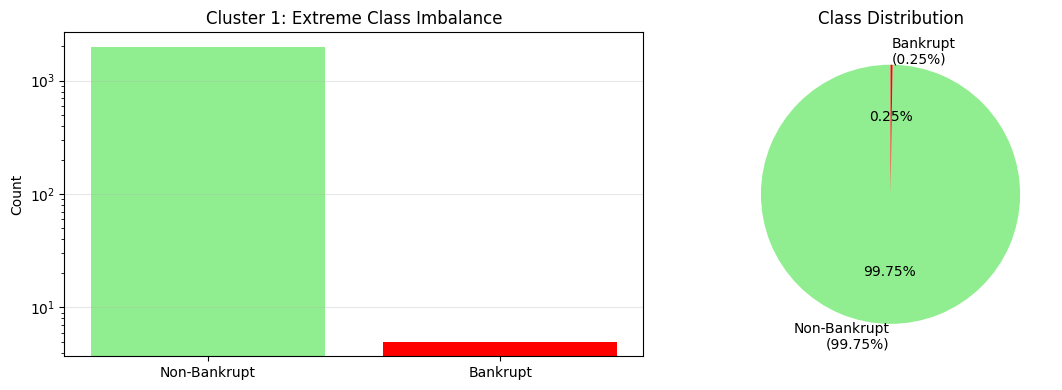

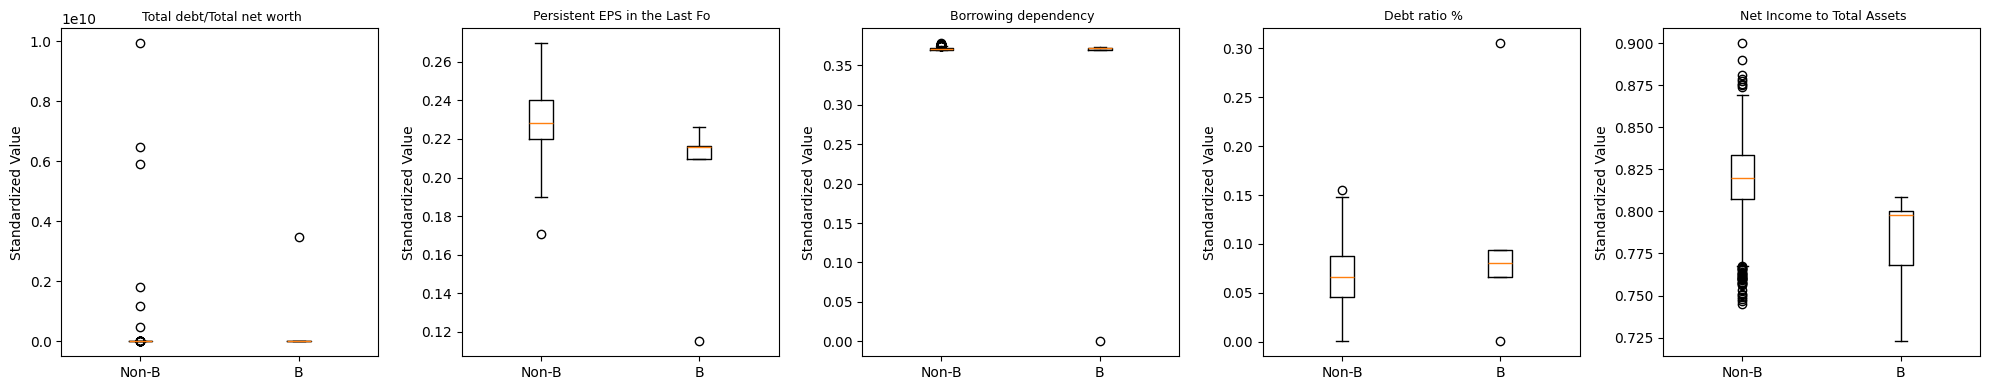

In [3]:
# PLOT 1: Class Imbalance Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Bar chart
axes[0].bar(['Non-Bankrupt', 'Bankrupt'], [1974, 5], color=['lightgreen', 'red'])
axes[0].set_ylabel('Count')
axes[0].set_title(f'Cluster {CLUSTER_ID}: Extreme Class Imbalance')
axes[0].set_yscale('log')  # Log scale to show the 5 bankruptcies
axes[0].grid(axis='y', alpha=0.3)

# Right: Pie chart
axes[1].pie([1974, 5], labels=['Non-Bankrupt\n(99.75%)', 'Bankrupt\n(0.25%)'], 
            colors=['lightgreen', 'red'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_class_distribution.png", dpi=300)
plt.show()

# PLOT 2: Top 5 Feature Distributions (Bankrupt vs Non-Bankrupt)
top_5_features = features_to_use[:5]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, feature in enumerate(top_5_features):
    bankrupt_vals = df[y == 1][feature]
    non_bankrupt_vals = df[y == 0][feature]
    
    axes[idx].boxplot([non_bankrupt_vals, bankrupt_vals], tick_labels=['Non-B', 'B'])
    axes[idx].set_title(feature[:30], fontsize=9)
    axes[idx].set_ylabel('Standardized Value')

plt.tight_layout()
plt.savefig(f"cluster{CLUSTER_ID}_feature_distributions.png", dpi=300)
plt.show()

In [4]:
# ==========================================
# 3. Define Base Models with SMOTE
# ==========================================
# Since we only have 5 positives, we use SMOTE to synthesize more 
# bankrupt examples so the models have something to learn.

# Base 1: Random Forest with SMOTE
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=1)), 
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

# Base 2: Gradient Boosting with SMOTE
gb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

# Base 3: KNN with SMOTE
# Note: KNN n_neighbors also reduced to 1 for the classifier itself to be safe
knn_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
    ('knn', KNeighborsClassifier(n_neighbors=1)) 
])

estimators = [
    ('rf', rf_pipeline),
    ('gb', gb_pipeline),
    ('knn', knn_pipeline)
]

In [5]:
# ==========================================
# 4. Define & Train Stacking Model
# ==========================================
# Important: We cannot use internal CV=5 because we only have 5 positive samples.
# If one fold gets 0 positives, it crashes. We use cv=2 to ensure at least 3 samples per fold.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

clf_stack = StackingClassifier(
    estimators=estimators,
    # AGGRESSIVE WEIGHTING: Treat 1 bankrupt error as 100 normal errors
    final_estimator=LogisticRegression(class_weight={0: 1, 1: 100}),
    cv=cv_strategy, 
    n_jobs=-1
)

print("\nTraining Stacking Model (with SMOTE k=1 + Aggressive Weights)...")
clf_stack.fit(X, y)
print("Training Complete.")


Training Stacking Model (with SMOTE k=1 + Aggressive Weights)...
Training Complete.


In [7]:
# ==========================================
# 5. Evaluation & Compliance (Table 3)
# ==========================================
def get_metrics(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    FF, FT, TF, TT = cm.ravel()
    
    # Equation 1 Accuracy: TT / (TF + TT)
    acc_eq1 = TT / (TF + TT) if (TF + TT) > 0 else 0
    
    print(f"{name}")
    print(f"Confusion Matrix: [[{FF}, {FT}], [{TF}, {TT}]]")
    print(f"Eq(1) Accuracy: {acc_eq1:.4f}")
    return FF, FT, TF, TT, acc_eq1

print(f"RESULTS FOR TABLE 3 (Cluster {CLUSTER_ID})")

# A. Base Model Performance
# We use the fitted base models inside the stack
print("\nBase Model Performance (on full train set):")
for name, est in clf_stack.named_estimators_.items():
    y_pred_base = est.predict(X)
    get_metrics(y, y_pred_base, f"Base: {name}")

# B. Stacking Model Performance
print("\nStacking Model Performance (Final):")
y_pred_stack = clf_stack.predict(X)
FF, FT, TF, TT, acc = get_metrics(y, y_pred_stack, "STACKING MODEL")

# ==========================================
# 6. Save Model Package
# ==========================================
model_package = {
    "cluster_id": CLUSTER_ID,
    "features": features_to_use,
    "model": clf_stack,
    "stats": {"TT": TT, "TF": TF, "N_features": len(features_to_use)}
}

joblib.dump(model_package, OUTPUT_MODEL)
print(f"\nModel saved to {OUTPUT_MODEL}")
print(f"Stats for Table 3 -> TT: {TT}, TF: {TF}")

RESULTS FOR TABLE 3 (Cluster 1)

Base Model Performance (on full train set):
Base: rf
Confusion Matrix: [[1974, 0], [0, 5]]
Eq(1) Accuracy: 1.0000
Base: gb
Confusion Matrix: [[1974, 0], [0, 5]]
Eq(1) Accuracy: 1.0000
Base: knn
Confusion Matrix: [[1974, 0], [1, 4]]
Eq(1) Accuracy: 0.8000

Stacking Model Performance (Final):
STACKING MODEL
Confusion Matrix: [[1972, 2], [0, 5]]
Eq(1) Accuracy: 1.0000

Model saved to cluster1_stacking.joblib
Stats for Table 3 -> TT: 5, TF: 0
